In [3]:
#Import important libraries
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error


In [5]:
# read the file
df = pd.read_csv('Water Quality.csv')
df

,DatasetName,MonitoringLocationID,MonitoringLocationName,MonitoringLocationLatitude,MonitoringLocationLongitude,MonitoringLocationHorizontalCoordinateReferenceSystem,MonitoringLocationHorizontalAccuracyMeasure,MonitoringLocationHorizontalAccuracyUnit,MonitoringLocationVerticalMeasure,MonitoringLocationVerticalUnit,...,ResultStatusID,ResultComment,ResultAnalyticalMethodID,ResultAnalyticalMethodContext,ResultAnalyticalMethodName,AnalysisStartDate,AnalysisStartTime,AnalysisStartTimeZone,LaboratoryName,LaboratorySampleID
0,Maritime Coastal Basin Long-term Water Quality...,NS01ED0005,MERSEY RIVER BELOW MILL FALLS SOUTH-WEST OF MA...,44.4367,-65.2228,NAD83,NaN,NaN,NaN,NaN,...,Preliminary,NaN,110688.0,ENV/CANADA,NaN,NaN,NaN,NaN,ECCCLabs,NaN
1,Maritime Coastal Basin Long-term Water Quality...,NS01ED0005,MERSEY RIVER BELOW MILL FALLS SOUTH-WEST OF MA...,44.4367,-65.2228,NAD83,NaN,NaN,NaN,NaN,...,Preliminary,NaN,2011.0,ENV/CANADA,NaN,NaN,NaN,NaN,ECCCLabs,NaN
2,Maritime Coastal Basin Long-term Water Quality...,NS01ED0005,MERSEY RIVER BELOW MILL FALLS SOUTH-WEST OF MA...,44.4367,-65.2228,NAD83,NaN,NaN,NaN,NaN,...,Preliminary,NaN,20110.0,ENV/CANADA,NaN,NaN,NaN,NaN,ECCCLabs,NaN
3,Maritime Coastal Basin Long-term Water Quality...,NS01ED0005,MERSEY RIVER BELOW MILL FALLS SOUTH-WEST OF MA...,44.4367,-65.2228,NAD83,NaN,NaN,NaN,NaN,...,Preliminary,NaN,17209.0,ENV/CANADA,NaN,NaN,NaN,NaN,ECCCLabs,NaN
4,Maritime Coastal Basin Long-term Water Quality...,NS01ED0005,MERSEY RIVER BELOW MILL FALLS SOUTH-WEST OF MA...,44.4367,-65.2228,NAD83,NaN,NaN,NaN,NaN,...,Preliminary,NaN,10110.0,ENV/CANADA,NaN,NaN,NaN,NaN,ECCCLabs,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27686,Maritime Coastal Basin Long-term Water Quality...,NS01ED0110,LOWER PINE MARTEN BOG AT OUTFLOW,44.4236,-65.2133,NAD83,NaN,NaN,NaN,NaN,...,Preliminary,NaN,110699.0,ENV/CANADA,NaN,NaN,NaN,NaN,ECCCLabs,NaN
27687,Maritime Coastal Basin Long-term Water Quality...,NS01ED0110,LOWER PINE MARTEN BOG AT OUTFLOW,44.4236,-65.2133,NAD83,NaN,NaN,NaN,NaN,...,Preliminary,NaN,3019.0,ENV/CANADA,NaN,NaN,NaN,NaN,ECCCLabs,NaN
27688,Maritime Coastal Basin Long-term Water Quality...,NS01ED0110,LOWER PINE MARTEN BOG AT OUTFLOW,44.4236,-65.2133,NAD83,NaN,NaN,NaN,NaN,...,Preliminary,NaN,10301.0,ENV/CANADA,NaN,NaN,NaN,NaN,ECCCLabs,NaN
27689,Maritime Coastal Basin Long-term Water Quality...,NS01ED0110,LOWER PINE MARTEN BOG AT OUTFLOW,44.4236,-65.2133,NAD83,NaN,NaN,NaN,NaN,...,Preliminary,NaN,102954.0,ENV/CANADA,NaN,NaN,NaN,NaN,ECCCLabs,NaN


In [7]:
# First five rows of dataset
df.head()

,DatasetName,MonitoringLocationID,MonitoringLocationName,MonitoringLocationLatitude,MonitoringLocationLongitude,MonitoringLocationHorizontalCoordinateReferenceSystem,MonitoringLocationHorizontalAccuracyMeasure,MonitoringLocationHorizontalAccuracyUnit,MonitoringLocationVerticalMeasure,MonitoringLocationVerticalUnit,...,ResultStatusID,ResultComment,ResultAnalyticalMethodID,ResultAnalyticalMethodContext,ResultAnalyticalMethodName,AnalysisStartDate,AnalysisStartTime,AnalysisStartTimeZone,LaboratoryName,LaboratorySampleID
0,Maritime Coastal Basin Long-term Water Quality...,NS01ED0005,MERSEY RIVER BELOW MILL FALLS SOUTH-WEST OF MA...,44.4367,-65.2228,NAD83,NaN,NaN,NaN,NaN,...,Preliminary,NaN,110688.0,ENV/CANADA,NaN,NaN,NaN,NaN,ECCCLabs,NaN
1,Maritime Coastal Basin Long-term Water Quality...,NS01ED0005,MERSEY RIVER BELOW MILL FALLS SOUTH-WEST OF MA...,44.4367,-65.2228,NAD83,NaN,NaN,NaN,NaN,...,Preliminary,NaN,2011.0,ENV/CANADA,NaN,NaN,NaN,NaN,ECCCLabs,NaN
2,Maritime Coastal Basin Long-term Water Quality...,NS01ED0005,MERSEY RIVER BELOW MILL FALLS SOUTH-WEST OF MA...,44.4367,-65.2228,NAD83,NaN,NaN,NaN,NaN,...,Preliminary,NaN,20110.0,ENV/CANADA,NaN,NaN,NaN,NaN,ECCCLabs,NaN
3,Maritime Coastal Basin Long-term Water Quality...,NS01ED0005,MERSEY RIVER BELOW MILL FALLS SOUTH-WEST OF MA...,44.4367,-65.2228,NAD83,NaN,NaN,NaN,NaN,...,Preliminary,NaN,17209.0,ENV/CANADA,NaN,NaN,NaN,NaN,ECCCLabs,NaN
4,Maritime Coastal Basin Long-term Water Quality...,NS01ED0005,MERSEY RIVER BELOW MILL FALLS SOUTH-WEST OF MA...,44.4367,-65.2228,NAD83,NaN,NaN,NaN,NaN,...,Preliminary,NaN,10110.0,ENV/CANADA,NaN,NaN,NaN,NaN,ECCCLabs,NaN


In [8]:
# Last five rows of dataset
df.tail()

,DatasetName,MonitoringLocationID,MonitoringLocationName,MonitoringLocationLatitude,MonitoringLocationLongitude,MonitoringLocationHorizontalCoordinateReferenceSystem,MonitoringLocationHorizontalAccuracyMeasure,MonitoringLocationHorizontalAccuracyUnit,MonitoringLocationVerticalMeasure,MonitoringLocationVerticalUnit,...,ResultStatusID,ResultComment,ResultAnalyticalMethodID,ResultAnalyticalMethodContext,ResultAnalyticalMethodName,AnalysisStartDate,AnalysisStartTime,AnalysisStartTimeZone,LaboratoryName,LaboratorySampleID
27686,Maritime Coastal Basin Long-term Water Quality...,NS01ED0110,LOWER PINE MARTEN BOG AT OUTFLOW,44.4236,-65.2133,NAD83,NaN,NaN,NaN,NaN,...,Preliminary,NaN,110699.0,ENV/CANADA,NaN,NaN,NaN,NaN,ECCCLabs,NaN
27687,Maritime Coastal Basin Long-term Water Quality...,NS01ED0110,LOWER PINE MARTEN BOG AT OUTFLOW,44.4236,-65.2133,NAD83,NaN,NaN,NaN,NaN,...,Preliminary,NaN,3019.0,ENV/CANADA,NaN,NaN,NaN,NaN,ECCCLabs,NaN
27688,Maritime Coastal Basin Long-term Water Quality...,NS01ED0110,LOWER PINE MARTEN BOG AT OUTFLOW,44.4236,-65.2133,NAD83,NaN,NaN,NaN,NaN,...,Preliminary,NaN,10301.0,ENV/CANADA,NaN,NaN,NaN,NaN,ECCCLabs,NaN
27689,Maritime Coastal Basin Long-term Water Quality...,NS01ED0110,LOWER PINE MARTEN BOG AT OUTFLOW,44.4236,-65.2133,NAD83,NaN,NaN,NaN,NaN,...,Preliminary,NaN,102954.0,ENV/CANADA,NaN,NaN,NaN,NaN,ECCCLabs,NaN
27690,Maritime Coastal Basin Long-term Water Quality...,NS01ED0110,LOWER PINE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Total count of rows and columns
df.shape

(27691, 40)

In [10]:
#Information about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27691 entries, 0 to 27690
Data columns (total 40 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   DatasetName                                            27691 non-null  object 
 1   MonitoringLocationID                                   27691 non-null  object 
 2   MonitoringLocationName                                 27691 non-null  object 
 3   MonitoringLocationLatitude                             27690 non-null  float64
 4   MonitoringLocationLongitude                            27690 non-null  float64
 5   MonitoringLocationHorizontalCoordinateReferenceSystem  27690 non-null  object 
 6   MonitoringLocationHorizontalAccuracyMeasure            0 non-null      float64
 7   MonitoringLocationHorizontalAccuracyUnit               0 non-null      float64
 8   MonitoringLocationVerticalMeasure             

In [11]:
# Statistical information of dataset
df.describe()

,MonitoringLocationLatitude,MonitoringLocationLongitude,MonitoringLocationHorizontalAccuracyMeasure,MonitoringLocationHorizontalAccuracyUnit,MonitoringLocationVerticalMeasure,MonitoringLocationVerticalUnit,ActivityEndDate,ActivityEndTime,ActivityDepthHeightMeasure,ActivityDepthHeightUnit,...,ResultDetectionCondition,ResultDetectionQuantitationLimitMeasure,ResultDetectionQuantitationLimitType,ResultComment,ResultAnalyticalMethodID,ResultAnalyticalMethodName,AnalysisStartDate,AnalysisStartTime,AnalysisStartTimeZone,LaboratorySampleID
count,27690.000000,27690.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,27690.000000,0.0,0.0,0.0,0.0,0.0
mean,44.829713,-64.618692,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,61815.980643,NaN,NaN,NaN,NaN,NaN
std,0.863729,1.391618,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,49458.515965,NaN,NaN,NaN,NaN,NaN
min,43.838100,-65.866700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,77.000000,NaN,NaN,NaN,NaN,NaN
25%,44.423600,-65.222800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,10111.000000,NaN,NaN,NaN,NaN,NaN
50%,44.436700,-65.212800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,102082.000000,NaN,NaN,NaN,NaN,NaN
75%,44.461900,-65.048300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,110695.000000,NaN,NaN,NaN,NaN,NaN
max,46.927500,-60.393900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,110706.000000,NaN,NaN,NaN,NaN,NaN


In [18]:
# Column names
df.columns


Index(['DatasetName', 'MonitoringLocationID', 'MonitoringLocationName',
       'MonitoringLocationLatitude', 'MonitoringLocationLongitude',
       'MonitoringLocationHorizontalCoordinateReferenceSystem',
       'MonitoringLocationHorizontalAccuracyMeasure',
       'MonitoringLocationHorizontalAccuracyUnit',
       'MonitoringLocationVerticalMeasure', 'MonitoringLocationVerticalUnit',
       'MonitoringLocationType', 'ActivityType', 'ActivityMediaName',
       'ActivityStartDate', 'ActivityStartTime', 'ActivityEndDate',
       'ActivityEndTime', 'ActivityDepthHeightMeasure',
       'ActivityDepthHeightUnit', 'SampleCollectionEquipmentName',
       'CharacteristicName', 'MethodSpeciation', 'ResultSampleFraction',
       'ResultValue', 'ResultUnit', 'ResultValueType',
       'ResultDetectionCondition', 'ResultDetectionQuantitationLimitMeasure',
       'ResultDetectionQuantitationLimitUnit',
       'ResultDetectionQuantitationLimitType', 'ResultStatusID',
       'ResultComment', 'ResultAna

Starting Water Quality Geospatial & ML Pipeline

 Performing Statistical EDA


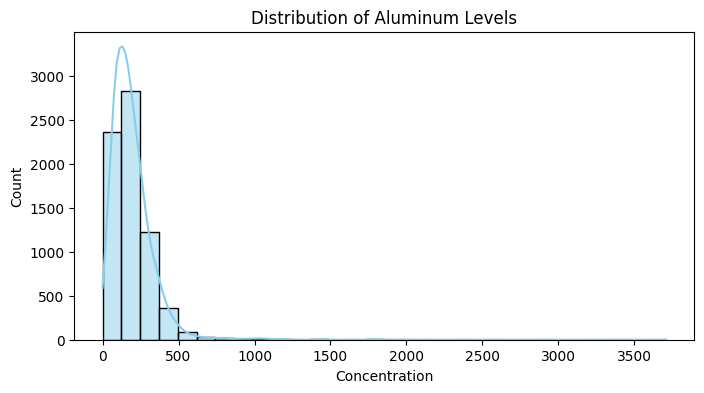

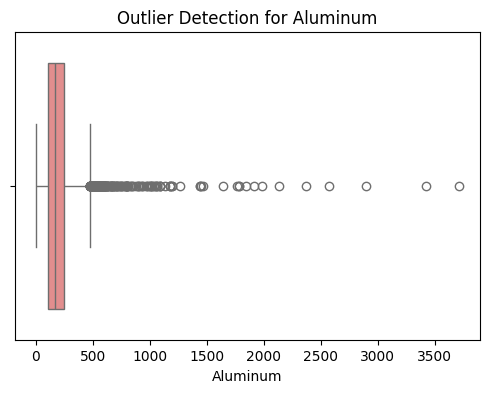

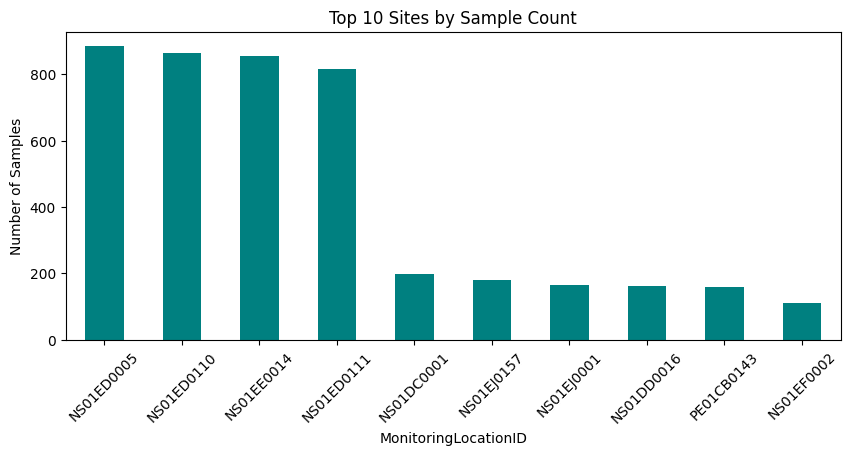


 Performing Geospatial Trend Analysis


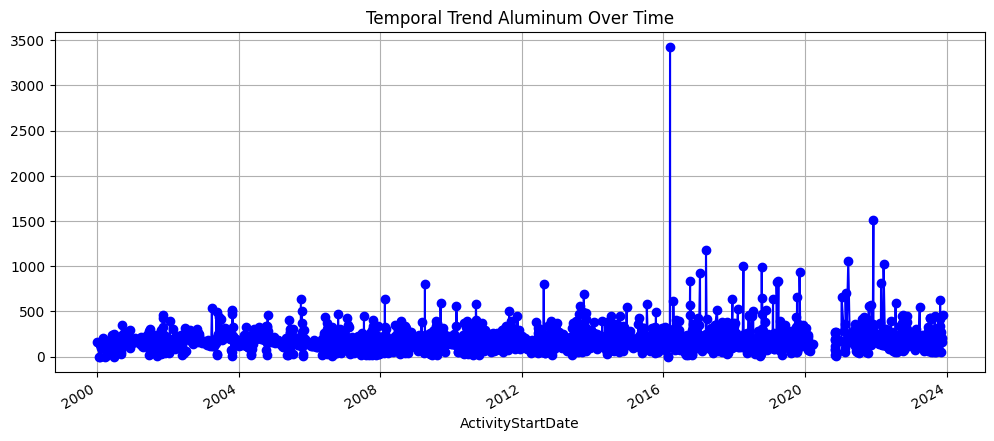

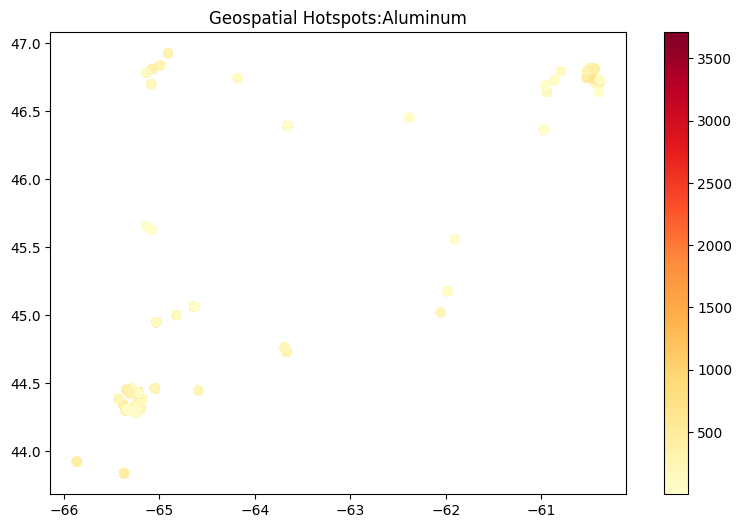


 Environmental Risk Modeling
Risk Assessment: 6940 samples flagged as High Risk.


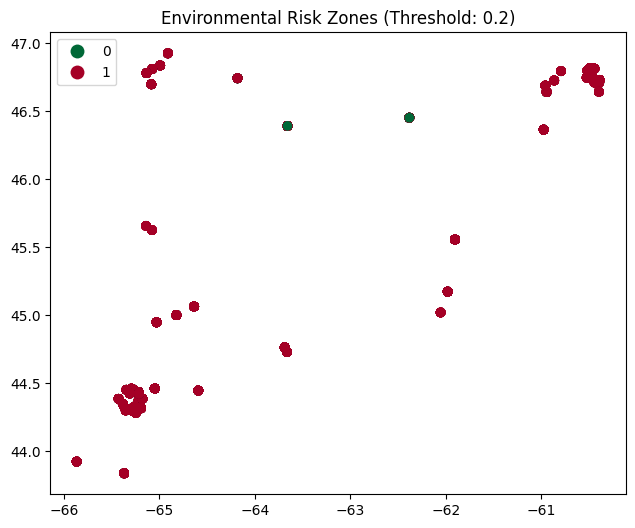


 ML Risk Model Performance
R2 Score: 0.8823785524223599


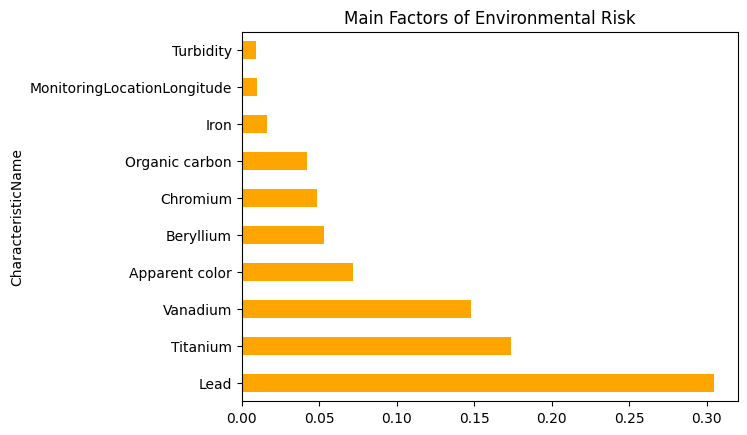


 Pipeline Completed Successfully!


In [21]:
# Load the file and set Target
FILE_PATH = 'Water Quality.csv'
TARGET_POLLUTANT = 'Aluminum'
RISK_THRESHOLD = 0.2
TEST_SIZE = 0.2
RANDOM_STATE = 42

def load_geospatial_data(path):
    df = pd.read_csv(path, low_memory=False)
    df = df.dropna(axis=1, how='all')
    df_pivot = df.pivot_table(
        index=[
            'MonitoringLocationID',
            'ActivityStartDate',
            'MonitoringLocationLatitude',
            'MonitoringLocationLongitude'
        ],
        columns='CharacteristicName',
        values='ResultValue',
        aggfunc='mean'
    ).reset_index()

    # date into standardise date format
    df_pivot['ActivityStartDate'] = pd.to_datetime(df_pivot['ActivityStartDate'])

    # Geospatial Analysis
    geometry = [Point(xy) for xy in zip(df_pivot['MonitoringLocationLongitude'], df_pivot['MonitoringLocationLatitude'])]
    gdf = gpd.GeoDataFrame(df_pivot, geometry=geometry, crs="EPSG:4269")

    return gdf

def perform_statistical_eda(gdf):
    print("\n Performing Statistical EDA")

    # Distribution of Target Pollutant
    plt.figure(figsize=(8, 4))
    sns.histplot(gdf[TARGET_POLLUTANT].dropna(), bins=30, kde=True, color='skyblue')
    plt.title(f"Distribution of {TARGET_POLLUTANT} Levels")
    plt.xlabel("Concentration")
    plt.show()

    # Outliers detection
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=gdf[TARGET_POLLUTANT], color='lightcoral')
    plt.title(f"Outlier Detection for {TARGET_POLLUTANT}")
    plt.show()

    # Samples per Monitoring (Top 10)
    plt.figure(figsize=(10, 4))
    gdf['MonitoringLocationID'].value_counts().nlargest(10).plot(kind='bar', color='teal')
    plt.title("Top 10 Sites by Sample Count")
    plt.ylabel("Number of Samples")
    plt.xticks(rotation=45)
    plt.show()

def geospatial_trend_analysis(gdf):
    print("\n Performing Geospatial Trend Analysis")

    # Trend
    temporal_trend = gdf.groupby('ActivityStartDate')[TARGET_POLLUTANT].mean()
    plt.figure(figsize=(12, 5))
    temporal_trend.plot(kind='line', marker='o', color='blue')
    plt.title(f"Temporal Trend {TARGET_POLLUTANT} Over Time")
    plt.grid(True)
    plt.show()

    # Spatial Distribution
    gdf.plot(column=TARGET_POLLUTANT, cmap='YlOrRd', legend=True, figsize=(10, 6))
    plt.title(f"Geospatial Hotspots:{TARGET_POLLUTANT}")
    plt.show()

def environmental_risk_modeling(gdf):
    print("\n Environmental Risk Modeling")

    # Define Risk:
    gdf['Risk_Level'] = (gdf[TARGET_POLLUTANT] > RISK_THRESHOLD).astype(int)

    print(f"Risk Assessment: {gdf['Risk_Level'].sum()} samples flagged as High Risk.")

    # Risk Zones
    gdf.plot(column='Risk_Level', categorical=True, legend=True,
             cmap='RdYlGn_r', figsize=(10, 6))
    plt.title(f"Environmental Risk Zones (Threshold: {RISK_THRESHOLD})")
    plt.show()

def train_ml_model(gdf):

    df_ml = gdf.dropna(subset=[TARGET_POLLUTANT]).fillna(0)

    # Features:
    X = df_ml.drop([TARGET_POLLUTANT, 'MonitoringLocationID', 'ActivityStartDate', 'geometry', 'Risk_Level'], axis=1, errors='ignore')
    y = df_ml[TARGET_POLLUTANT]

    x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

    model = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
    model.fit(x_train, y_train)

    return model, x_test, y_test

def evaluate_model(model, x_test, y_test):
    y_pred = model.predict(x_test)
    print("\n ML Risk Model Performance")
    print("R2 Score:", r2_score(y_test, y_pred))

    # Risk factors
    feat_importances = pd.Series(model.feature_importances_, index=x_test.columns)
    feat_importances.nlargest(10).plot(kind='barh', color='orange')
    plt.title("Main Factors of Environmental Risk")
    plt.show()

def main():
    print("Starting Water Quality Geospatial & ML Pipeline")
    try:
        gdf = load_geospatial_data(FILE_PATH)

        if TARGET_POLLUTANT in gdf.columns:
            perform_statistical_eda(gdf)
            geospatial_trend_analysis(gdf)
            environmental_risk_modeling(gdf)
            model, x_test, y_test = train_ml_model(gdf)
            evaluate_model(model, x_test, y_test)
            print("\n Pipeline Completed Successfully!")
        else:
            print(f"Error: '{TARGET_POLLUTANT}' not found in CharacteristicName")

    except Exception as e:
        print(f"An unexpected error occurred: {e}")

if __name__ == "__main__":
    main()


In [22]:
df.to_csv("water_quality_cleaned.csv")